Explained variance ratio: [0.7296 0.2285]
Cumulative explained variance: [0.7296 0.9581]


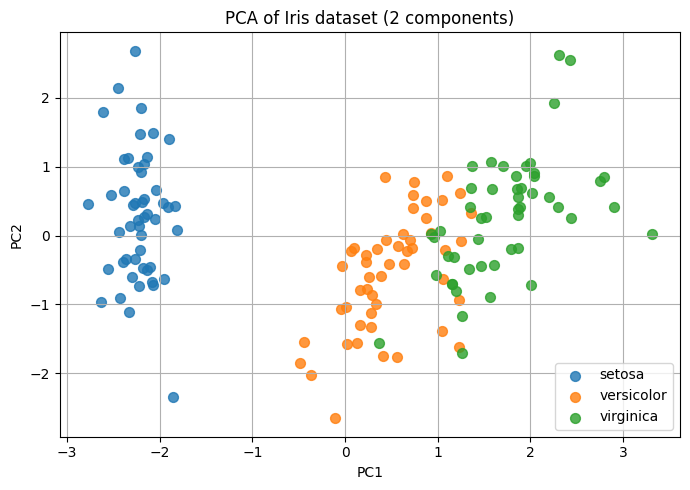

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA example on Iris dataset (cell index 0)
import matplotlib.pyplot as plt

# Load data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")
target_names = iris.target_names

# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA (2 components)
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df = pd.concat([pca_df, y], axis=1)

# Print explained variance
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Cumulative explained variance:", np.round(np.cumsum(pca.explained_variance_ratio_), 4))

# Scatter plot of the first two principal components
colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(7,5))
for i, target in enumerate(np.unique(y)):
    mask = pca_df["species"] == target
    plt.scatter(pca_df.loc[mask, "PC1"],
                pca_df.loc[mask, "PC2"],
                label=target_names[target],
                alpha=0.8,
                s=50,
                color=colors[i])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Iris dataset (2 components)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()